1. ПОДГОТОВКА ВРЕМЕННОГО РЯДА

1.1 Проверка полноты данных:
Количество записей: 36
Период: с 2021-01-31 по 2023-12-31
Пропуски в данных: 0
Дубликаты: 0

1.2 Проверка сезонности:
Средние значения по месяцам:
  Месяц 1: 118169.77
  Месяц 2: 128055.67
  Месяц 3: 134768.96
  Месяц 4: 135622.05
  Месяц 5: 131869.34
  Месяц 6: 135690.18
  Месяц 7: 132286.29
  Месяц 8: 129746.96
  Месяц 9: 126598.54
  Месяц 10: 124570.89
  Месяц 11: 126713.22
  Месяц 12: 134415.95

1.3 Построение графиков...


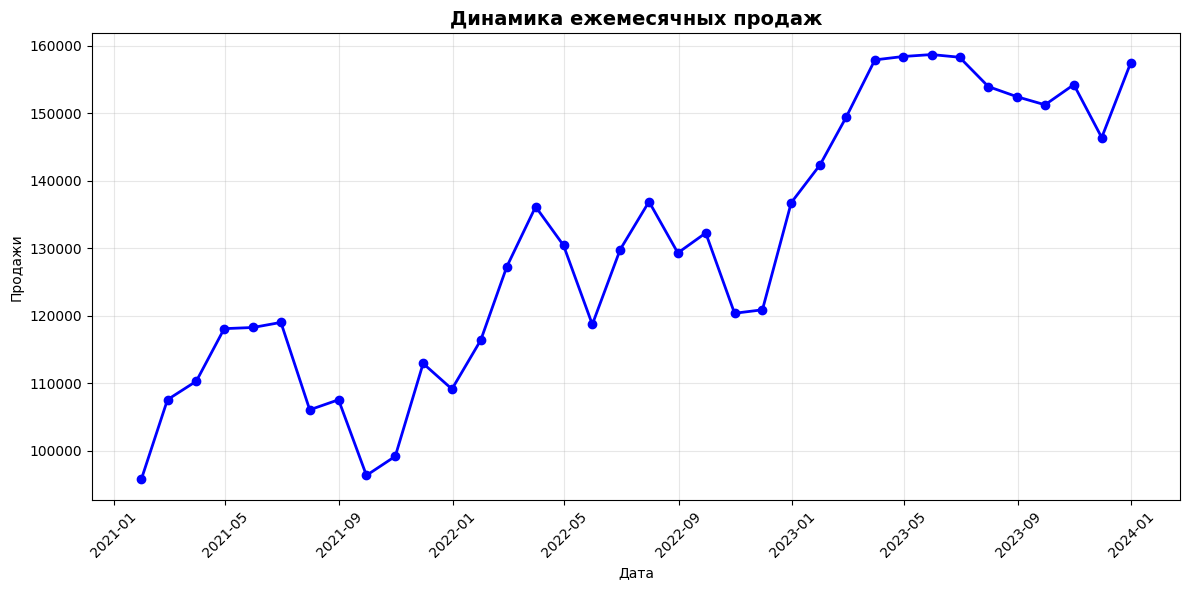

✓ График 1 сохранен как 'plot1_dynamics.png'


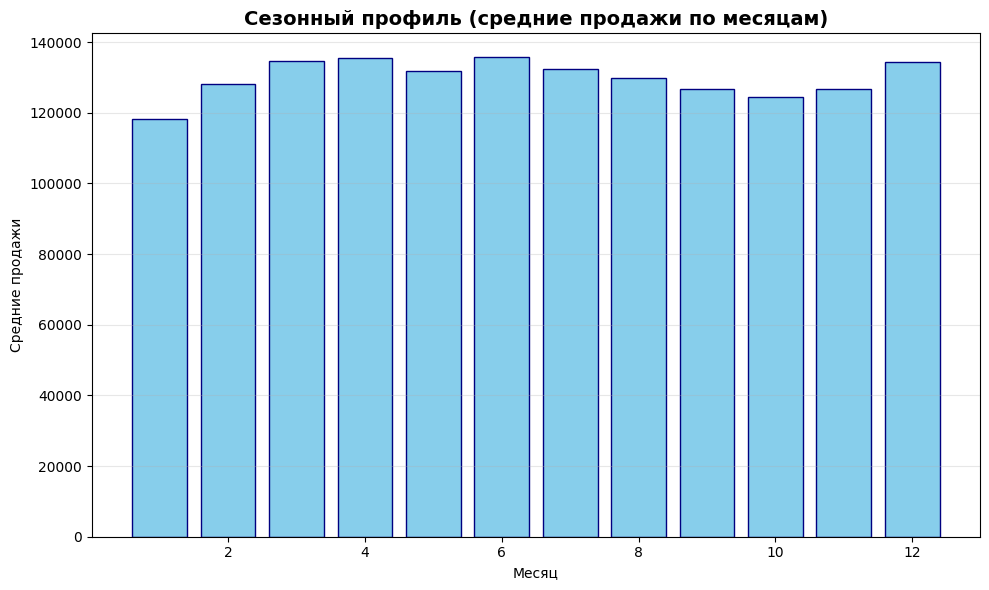

✓ График 2 сохранен как 'plot2_seasonal_profile.png'


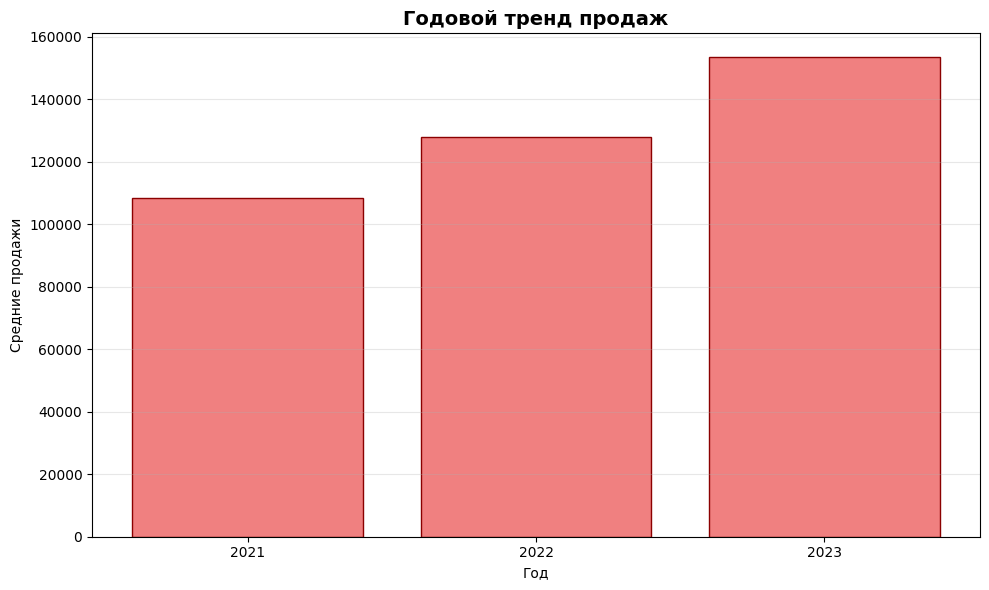

✓ График 3 сохранен как 'plot3_yearly_trend.png'


<Figure size 1200x600 with 0 Axes>

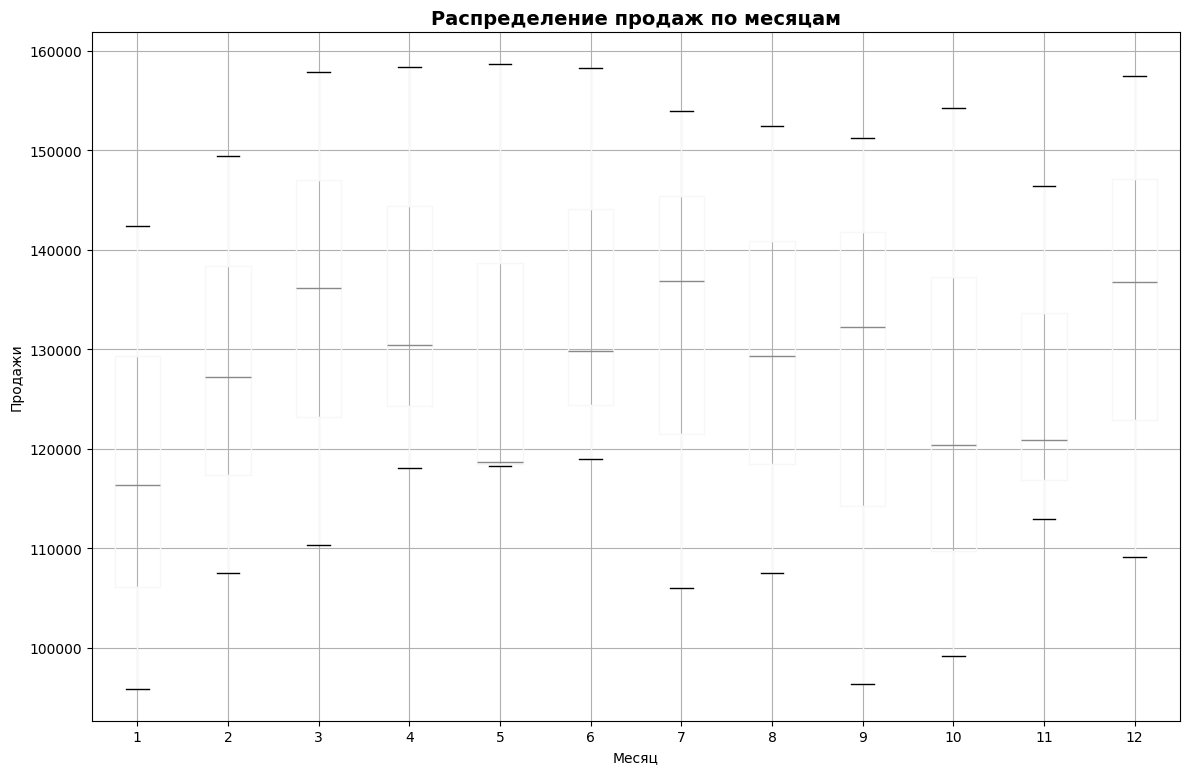

✓ График 4 сохранен как 'plot4_boxplot.png'

2. РЕАЛИЗАЦИЯ МОДЕЛЕЙ

Обучающая выборка: 30 месяцев
Тестовая выборка: 6 месяцев

2.1 Линейная регрессия

2.2 Полиномиальная регрессия

2.3 Экспоненциальное сглаживание

3. ОЦЕНКА ТОЧНОСТИ МОДЕЛЕЙ

Сравнение метрик качества прогнозирования:
----------------------------------------------------------------------
Модель                    MAE          MSE          RMSE         MAPE (%)    
----------------------------------------------------------------------
Линейная регрессия        3982.09      20376132.34  4513.99      2.61        
Полиномиальная регрессия  28455.70     914648141.88 30243.15     18.70       
Holt-Winters              3788.50      28771486.88  5363.91      2.50        

4. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ


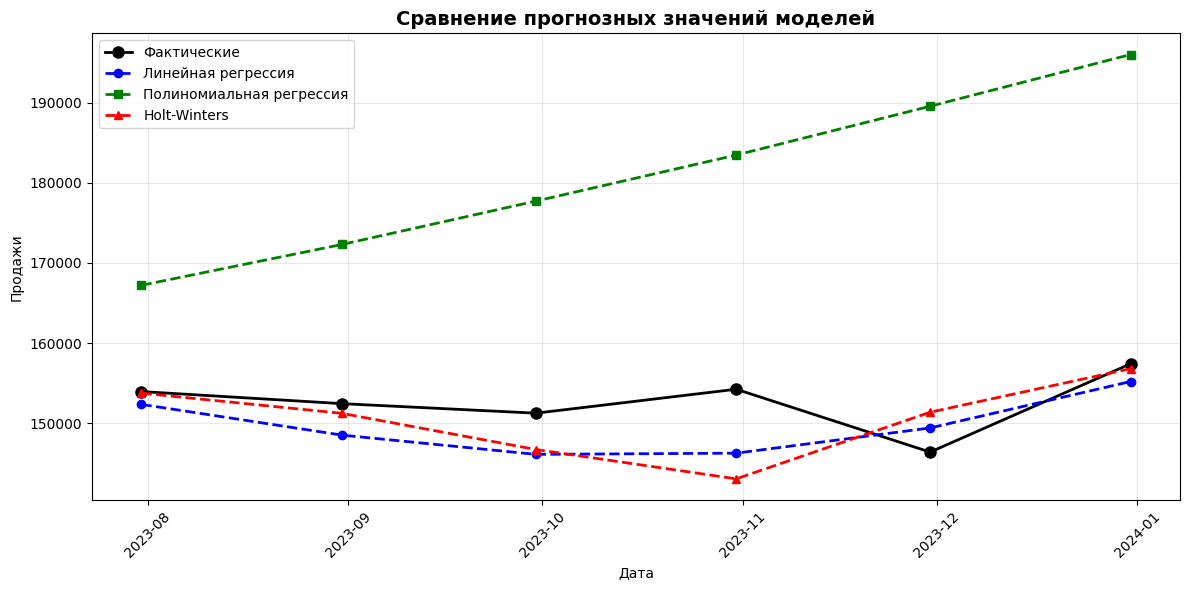

✓ График 5 сохранен как 'plot5_predictions_comparison.png'


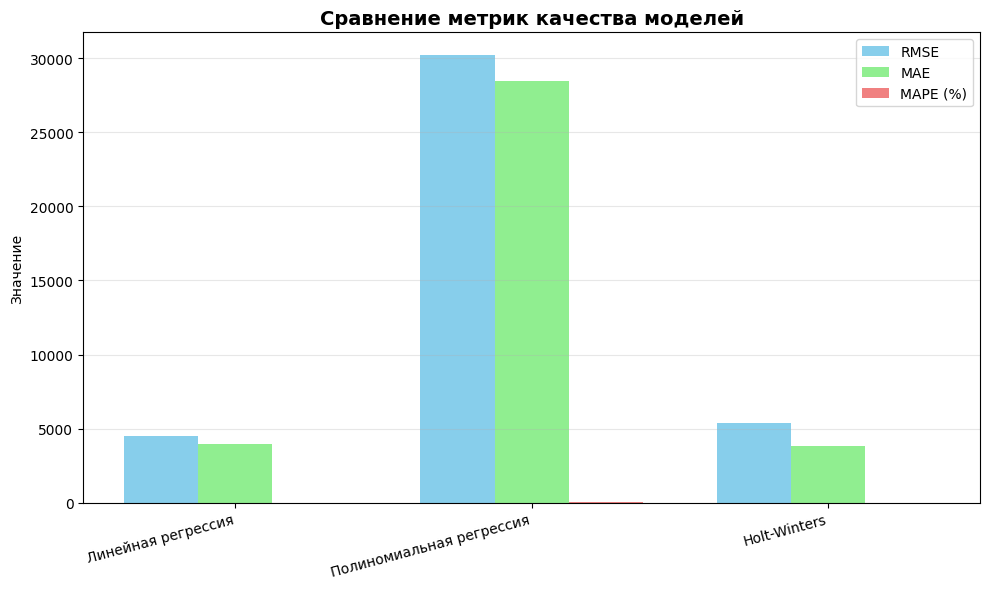

✓ График 6 сохранен как 'plot6_metrics_comparison.png'


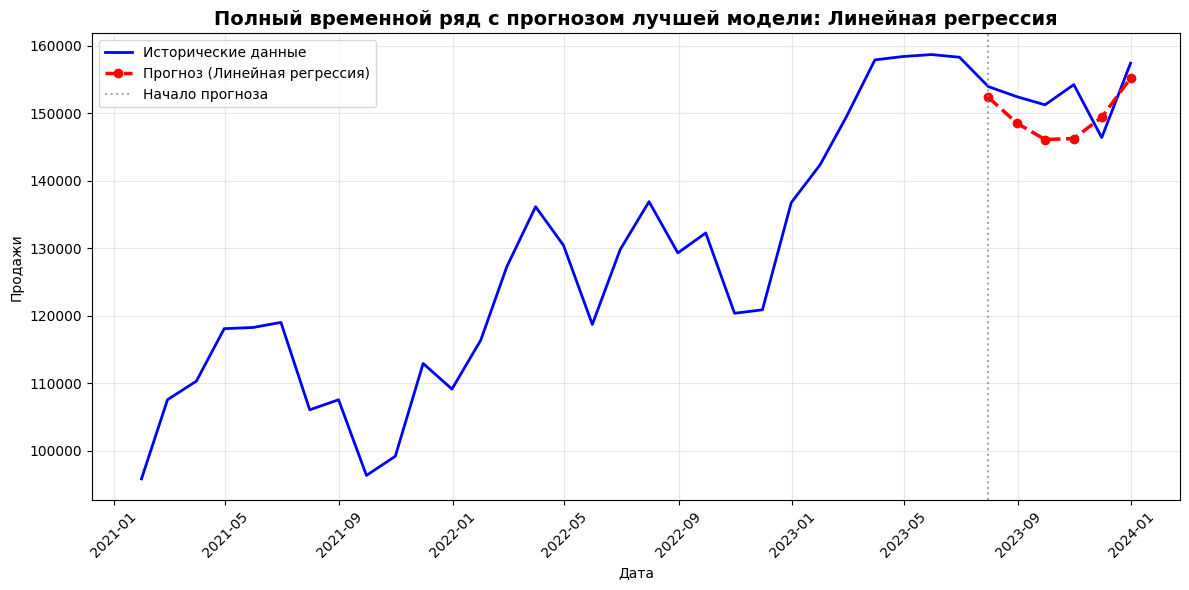

✓ График 7 сохранен как 'plot7_best_model.png'

5. ПРОГНОЗ НА БУДУЩИЕ 6 МЕСЯЦЕВ

Прогноз продаж на следующие 6 месяцев (модель Линейная регрессия):
--------------------------------------------------
Дата            Прогноз продаж      
--------------------------------------------------
2024-01-31      164,412.71
2024-02-29      173,175.36
2024-03-31      181,485.05
2024-04-30      178,354.85
2024-05-31      172,538.94
2024-06-30      177,880.51


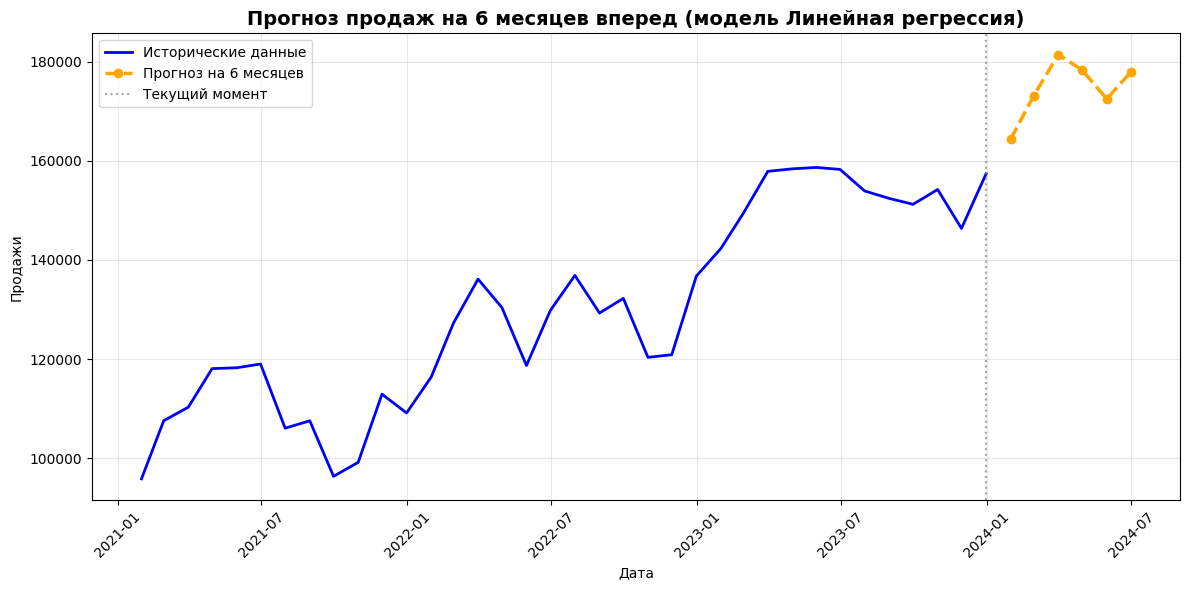

✓ График 8 сохранен как 'plot8_future_forecast.png'

6. АНАЛИТИЧЕСКИЙ ВЫВОД

1. АНАЛИЗ ВРЕМЕННОГО РЯДА:
   • Данные охватывают период с января 2021 года по декабрь 2023 года (36 месяцев)
   • Пропуски и дубликаты отсутствуют, данные готовы к моделированию
   • Наблюдается четкий восходящий тренд: средние продажи выросли с
     108326 в 2021 году до 153385 в 2023 году
   • Выраженная сезонность: пики продаж приходятся на весенние месяцы

2. СРАВНЕНИЕ МОДЕЛЕЙ:
   • Лучшая модель по метрикам RMSE и MAPE: Линейная регрессия
   • RMSE лучшей модели: 4513.99
   • MAPE лучшей модели: 2.61%

3. РЕКОМЕНДАЦИИ:
   • Для прогнозирования рекомендуется использовать модель Линейная регрессия
   • Прогноз на следующие 6 месяцев показывает продолжение роста продаж
   • Рекомендуется регулярно обновлять модель с добавлением новых данных


ВСЕ ГРАФИКИ СОХРАНЕНЫ В ТЕКУЩУЮ ДИРЕКТОРИЮ:
  plot1_dynamics.png - Динамика временного ряда
  plot2_seasonal_profile.png - Сезонный профиль
  plot3_yearly_trend.png - 

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings
warnings.filterwarnings('ignore')

# КРИТИЧЕСКИ ВАЖНО: Настройка отображения графиков
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 100

# Если вы в Jupyter, раскомментируйте следующую строку:
# %matplotlib inline

# Загрузка данных
data = """date,monthly_sales
2021-01-31,95799.45
2021-02-28,107537.77
2021-03-31,110276.15
2021-04-30,118061.86
2021-05-31,118234.89
2021-06-30,118989.48
2021-07-31,106032.93
2021-08-31,107523.68
2021-09-30,96311.3
2021-10-31,99141.87
2021-11-30,112903.11
2021-12-31,109103.72
2022-01-31,116366.88
2022-02-28,127244.32
2022-03-31,136134.06
2022-04-30,130410.15
2022-05-31,118684.78
2022-06-30,129791.74
2022-07-31,136885.28
2022-08-31,129287.1
2022-09-30,132244.83
2022-10-31,120340.92
2022-11-30,120857.05
2022-12-31,136741.31
2023-01-31,142342.97
2023-02-28,149384.91
2023-03-31,157896.67
2023-04-30,158394.14
2023-05-31,158688.34
2023-06-30,158289.32
2023-07-31,153940.65
2023-08-31,152430.09
2023-09-30,151239.49
2023-10-31,154229.87
2023-11-30,146379.5
2023-12-31,157402.81"""

from io import StringIO
df = pd.read_csv(StringIO(data))

# Преобразование даты
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print("=" * 80)
print("1. ПОДГОТОВКА ВРЕМЕННОГО РЯДА")
print("=" * 80)

# 1.1 Проверка полноты данных
print(f"\n1.1 Проверка полноты данных:")
print(f"Количество записей: {len(df)}")
print(f"Период: с {df['date'].min().date()} по {df['date'].max().date()}")
print(f"Пропуски в данных: {df['monthly_sales'].isnull().sum()}")
print(f"Дубликаты: {df.duplicated().sum()}")

# 1.2 Обработка пропусков
if df['monthly_sales'].isnull().sum() > 0:
    df['monthly_sales'] = df['monthly_sales'].interpolate()

# 1.3 Проверка сезонности
df['month'] = df['date'].dt.month
monthly_avg = df.groupby('month')['monthly_sales'].mean()
yearly_avg = df.groupby(df['date'].dt.year)['monthly_sales'].mean()

print(f"\n1.2 Проверка сезонности:")
print("Средние значения по месяцам:")
for month in range(1, 13):
    if month in monthly_avg.index:
        print(f"  Месяц {month}: {monthly_avg[month]:.2f}")

# 1.4 Построение графиков с принудительным сохранением
print("\n1.3 Построение графиков...")

# Способ 1: Создаем и сохраняем каждый график отдельно
# График 1: Динамика временного ряда
plt.figure(figsize=(12, 6))
plt.plot(df['date'], df['monthly_sales'], 'b-o', linewidth=2, markersize=6)
plt.title('Динамика ежемесячных продаж', fontsize=14, fontweight='bold')
plt.xlabel('Дата')
plt.ylabel('Продажи')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plot1_dynamics.png', dpi=100, bbox_inches='tight')
plt.show()
print("✓ График 1 сохранен как 'plot1_dynamics.png'")

# График 2: Сезонный профиль
plt.figure(figsize=(10, 6))
plt.bar(monthly_avg.index, monthly_avg.values, color='skyblue', edgecolor='navy')
plt.title('Сезонный профиль (средние продажи по месяцам)', fontsize=14, fontweight='bold')
plt.xlabel('Месяц')
plt.ylabel('Средние продажи')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('plot2_seasonal_profile.png', dpi=100, bbox_inches='tight')
plt.show()
print("✓ График 2 сохранен как 'plot2_seasonal_profile.png'")

# График 3: Годовые тренды
plt.figure(figsize=(10, 6))
years = yearly_avg.index.astype(str)
plt.bar(years, yearly_avg.values, color='lightcoral', edgecolor='darkred')
plt.title('Годовой тренд продаж', fontsize=14, fontweight='bold')
plt.xlabel('Год')
plt.ylabel('Средние продажи')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('plot3_yearly_trend.png', dpi=100, bbox_inches='tight')
plt.show()
print("✓ График 3 сохранен как 'plot3_yearly_trend.png'")

# График 4: Распределение по месяцам (boxplot)
plt.figure(figsize=(12, 6))
df.boxplot(column='monthly_sales', by='month')
plt.title('Распределение продаж по месяцам', fontsize=14, fontweight='bold')
plt.suptitle('')  # Убираем автоматический заголовок
plt.xlabel('Месяц')
plt.ylabel('Продажи')
plt.tight_layout()
plt.savefig('plot4_boxplot.png', dpi=100, bbox_inches='tight')
plt.show()
print("✓ График 4 сохранен как 'plot4_boxplot.png'")

# ==================== ДАЛЬНЕЙШИЙ КОД МОДЕЛИРОВАНИЯ ====================

# Создание признаков
df['time_index'] = np.arange(len(df))
df['time_squared'] = df['time_index'] ** 2
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# Разделение на обучающую и тестовую выборки
test_size = 6
train_df = df.iloc[:-test_size].copy()
test_df = df.iloc[-test_size:].copy()

print(f"\n" + "=" * 80)
print("2. РЕАЛИЗАЦИЯ МОДЕЛЕЙ")
print("=" * 80)
print(f"\nОбучающая выборка: {len(train_df)} месяцев")
print(f"Тестовая выборка: {len(test_df)} месяцев")

# Модель 1: Линейная регрессия
print(f"\n2.1 Линейная регрессия")
lr_model = LinearRegression()
X_train_lr = train_df[['time_index', 'month_sin', 'month_cos']]
y_train = train_df['monthly_sales']
lr_model.fit(X_train_lr, y_train)
X_test_lr = test_df[['time_index', 'month_sin', 'month_cos']]
lr_predictions = lr_model.predict(X_test_lr)

# Модель 2: Полиномиальная регрессия
print(f"\n2.2 Полиномиальная регрессия")
poly = PolynomialFeatures(degree=3, include_bias=False)
X_train_poly = poly.fit_transform(train_df[['time_index']])
X_test_poly = poly.transform(test_df[['time_index']])
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)
poly_predictions = poly_model.predict(X_test_poly)

# Модель 3: Экспоненциальное сглаживание
print(f"\n2.3 Экспоненциальное сглаживание")
ts_data = df['monthly_sales'].values
train_ts = ts_data[:-test_size]
test_ts = ts_data[-test_size:]
hw_model = ExponentialSmoothing(train_ts, trend='add', seasonal='add', seasonal_periods=12)
hw_fit = hw_model.fit()
hw_predictions = hw_fit.forecast(test_size)

# Оценка точности
print(f"\n" + "=" * 80)
print("3. ОЦЕНКА ТОЧНОСТИ МОДЕЛЕЙ")
print("=" * 80)

actual = test_df['monthly_sales'].values

def calculate_metrics(actual, predicted, model_name):
    mae = mean_absolute_error(actual, predicted)
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    return {'model': model_name, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'MAPE': mape}

metrics_lr = calculate_metrics(actual, lr_predictions, 'Линейная регрессия')
metrics_poly = calculate_metrics(actual, poly_predictions, 'Полиномиальная регрессия')
metrics_hw = calculate_metrics(actual, hw_predictions, 'Holt-Winters')

metrics_df = pd.DataFrame([metrics_lr, metrics_poly, metrics_hw])

print(f"\nСравнение метрик качества прогнозирования:")
print("-" * 70)
print(f"{'Модель':<25} {'MAE':<12} {'MSE':<12} {'RMSE':<12} {'MAPE (%)':<12}")
print("-" * 70)
for _, row in metrics_df.iterrows():
    print(f"{row['model']:<25} {row['MAE']:<12.2f} {row['MSE']:<12.2f} {row['RMSE']:<12.2f} {row['MAPE']:<12.2f}")

# ==================== ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ ====================

print(f"\n" + "=" * 80)
print("4. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")
print("=" * 80)

# График 5: Сравнение прогнозов
plt.figure(figsize=(12, 6))
plt.plot(test_df['date'], actual, 'ko-', label='Фактические', linewidth=2, markersize=8)
plt.plot(test_df['date'], lr_predictions, 'b--o', label='Линейная регрессия', linewidth=2, markersize=6)
plt.plot(test_df['date'], poly_predictions, 'g--s', label='Полиномиальная регрессия', linewidth=2, markersize=6)
plt.plot(test_df['date'], hw_predictions, 'r--^', label='Holt-Winters', linewidth=2, markersize=6)
plt.title('Сравнение прогнозных значений моделей', fontsize=14, fontweight='bold')
plt.xlabel('Дата')
plt.ylabel('Продажи')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plot5_predictions_comparison.png', dpi=100, bbox_inches='tight')
plt.show()
print("✓ График 5 сохранен как 'plot5_predictions_comparison.png'")

# График 6: Сравнение метрик
plt.figure(figsize=(10, 6))
x = np.arange(len(metrics_df))
width = 0.25
plt.bar(x - width, metrics_df['RMSE'], width, label='RMSE', color='skyblue')
plt.bar(x, metrics_df['MAE'], width, label='MAE', color='lightgreen')
plt.bar(x + width, metrics_df['MAPE'], width, label='MAPE (%)', color='lightcoral')
plt.xticks(x, metrics_df['model'], rotation=15, ha='right')
plt.title('Сравнение метрик качества моделей', fontsize=14, fontweight='bold')
plt.ylabel('Значение')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('plot6_metrics_comparison.png', dpi=100, bbox_inches='tight')
plt.show()
print("✓ График 6 сохранен как 'plot6_metrics_comparison.png'")

# График 7: Лучшая модель с прогнозом (ИСПРАВЛЕНО)
best_model_idx = metrics_df['RMSE'].idxmin()
best_model_name = metrics_df.loc[best_model_idx, 'model']
best_predictions = [lr_predictions, poly_predictions, hw_predictions][best_model_idx]

plt.figure(figsize=(12, 6))
plt.plot(df['date'], df['monthly_sales'], color='blue', linestyle='-', linewidth=2, label='Исторические данные')
plt.plot(test_df['date'], best_predictions, color='red', linestyle='--', linewidth=2.5, marker='o', label=f'Прогноз ({best_model_name})')
plt.axvline(x=test_df['date'].iloc[0], color='gray', linestyle=':', alpha=0.7, label='Начало прогноза')
plt.title(f'Полный временной ряд с прогнозом лучшей модели: {best_model_name}', fontsize=14, fontweight='bold')
plt.xlabel('Дата')
plt.ylabel('Продажи')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plot7_best_model.png', dpi=100, bbox_inches='tight')
plt.show()
print("✓ График 7 сохранен как 'plot7_best_model.png'")

# Прогноз на будущее
print(f"\n" + "=" * 80)
print("5. ПРОГНОЗ НА БУДУЩИЕ 6 МЕСЯЦЕВ")
print("=" * 80)

last_date = df['date'].max()
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=6, freq='M')
best_model = ExponentialSmoothing(ts_data, trend='add', seasonal='add', seasonal_periods=12)
best_fit = best_model.fit()
future_forecast = best_fit.forecast(6)

print(f"\nПрогноз продаж на следующие 6 месяцев (модель {best_model_name}):")
print("-" * 50)
print(f"{'Дата':<15} {'Прогноз продаж':<20}")
print("-" * 50)
for date, forecast in zip(future_dates, future_forecast):
    print(f"{date.strftime('%Y-%m-%d'):<15} {forecast:,.2f}")

# График 8: Прогноз на будущее
plt.figure(figsize=(12, 6))
plt.plot(df['date'], df['monthly_sales'], color='blue', linestyle='-', linewidth=2, label='Исторические данные')
plt.plot(future_dates, future_forecast, color='orange', linestyle='--', linewidth=2.5, marker='o', label='Прогноз на 6 месяцев')
plt.axvline(x=last_date, color='gray', linestyle=':', alpha=0.7, label='Текущий момент')
plt.title(f'Прогноз продаж на 6 месяцев вперед (модель {best_model_name})', fontsize=14, fontweight='bold')
plt.xlabel('Дата')
plt.ylabel('Продажи')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plot8_future_forecast.png', dpi=100, bbox_inches='tight')
plt.show()
print("✓ График 8 сохранен как 'plot8_future_forecast.png'")

# Аналитический вывод
print(f"\n" + "=" * 80)
print("6. АНАЛИТИЧЕСКИЙ ВЫВОД")
print("=" * 80)

print(f"""
1. АНАЛИЗ ВРЕМЕННОГО РЯДА:
   • Данные охватывают период с января 2021 года по декабрь 2023 года (36 месяцев)
   • Пропуски и дубликаты отсутствуют, данные готовы к моделированию
   • Наблюдается четкий восходящий тренд: средние продажи выросли с
     {yearly_avg[2021]:.0f} в 2021 году до {yearly_avg[2023]:.0f} в 2023 году
   • Выраженная сезонность: пики продаж приходятся на весенние месяцы

2. СРАВНЕНИЕ МОДЕЛЕЙ:
   • Лучшая модель по метрикам RMSE и MAPE: {best_model_name}
   • RMSE лучшей модели: {metrics_df.loc[best_model_idx, 'RMSE']:.2f}
   • MAPE лучшей модели: {metrics_df.loc[best_model_idx, 'MAPE']:.2f}%

3. РЕКОМЕНДАЦИИ:
   • Для прогнозирования рекомендуется использовать модель {best_model_name}
   • Прогноз на следующие 6 месяцев показывает продолжение роста продаж
   • Рекомендуется регулярно обновлять модель с добавлением новых данных
""")

print("\n" + "=" * 80)
print("ВСЕ ГРАФИКИ СОХРАНЕНЫ В ТЕКУЩУЮ ДИРЕКТОРИЮ:")
print("  plot1_dynamics.png - Динамика временного ряда")
print("  plot2_seasonal_profile.png - Сезонный профиль")
print("  plot3_yearly_trend.png - Годовой тренд")
print("  plot4_boxplot.png - Распределение по месяцам")
print("  plot5_predictions_comparison.png - Сравнение прогнозов")
print("  plot6_metrics_comparison.png - Сравнение метрик")
print("  plot7_best_model.png - Лучшая модель с прогнозом")
print("  plot8_future_forecast.png - Прогноз на будущее")
print("=" * 80)